In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import test as test
import networkx as nx

In [19]:
epidist_data = pd.read_csv('./Data/epidist.csv')
bepidist_data = pd.read_csv('./Data/bepidist.csv')
epidist_data =  epidist_data.drop(columns=['Unnamed: 0']).iloc[1: , :]
epidist_data.columns = ['day', 's_mean', 's_min', 's_max', 'i_mean', 'i_min', 'i_max', 
'r_mean', 'r_min', 'r_max', 'V', 'T']
bepidist_data =  bepidist_data.drop(columns=['Unnamed: 0']).iloc[1: , :]
bepidist_data.columns = ['day', 's_mean', 's_min', 's_max', 'i_mean', 'i_min', 'i_max', 
'r_mean', 'r_min', 'r_max', 'edgecount_mean', 'edgecount_min', 'edgecount_max',
'suscedgecount_mean', 'suscedgecount_min', 'suscedgecount_max', 'V', 'T']
epidist_data = epidist_data.apply(pd.to_numeric)
bepidist_data = bepidist_data.apply(pd.to_numeric)

### Example of disease peaks differences depeding on utility shape parameter

0.0021999999999999797
0.013000000000000012
0.27979999999999994
0.41059999999999997


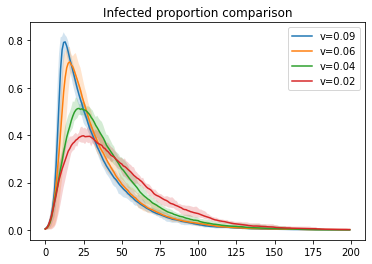

In [20]:
vs = [0.09, 0.06, 0.04, 0.02]
T = 7
n = 500

plt.figure()

for v in vs:

    epidist = epidist_data[(epidist_data['V'] == v) & (epidist_data['T'] == T)]
    bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]

    mean = (epidist['i_mean']/n).tolist()
    lower = (epidist['i_min']/n).tolist()
    upper = (epidist['i_max']/n).tolist()

    meanb = (bepidist['i_mean']/n).tolist()
    lowerb = (bepidist['i_min']/n).tolist()
    upperb = (bepidist['i_max']/n).tolist()

    diff = np.nanmax(mean) - np.nanmax(meanb)
    print(diff)

    # plt.plot(mean,'-b', label="Mean classic model")
    # # fill the area with black color, opacity 0.15
    # plt.fill_between(list(range(len(mean))), upper, lower, color="b", alpha=0.2)

    plt.plot(meanb, label=f"v={v}")
    # fill the area with black color, opacity 0.15
    plt.fill_between(list(range(len(meanb))), upperb, lowerb, alpha=0.2)

plt.title("Infected proportion comparison")
plt.legend(loc="upper right")

plt.show()

{0.3008,0.4106,0.3934,0.2798,0.1786,0.013,0.0154,0.074,0.0022,0.05},
{0.3984,0.2678,0.071,0.0072,0.0006,0.0686,0.0206,0.0172,0.0432,0.0072},
{0.3888,0.0674,0.0828,0.0434,0.099,0.003,0.025,0.0282,0.057,0.0926},
{0.0644,0.0062,0.0012,0.0346,0.011,0.0742,0.0374,0.0102,0.0826,0.0528},
{0.0836,0.0766,0.0238,0.0196,0.2168,0.1022,0.0052,0.0294,0.1264,0.0364},
{0.0216,0.0762,0.0152,0.0072,0.03,0.0698,0.0016,0.1034,0.0892,0.0786},
{0.032,0.1682,0.0036,0.0066,0.061,0.0638,0.112,0.0678,0.0036,0.0048},
{0.1054,0.0952,0.0058,0.0436,0.0268,0.0996,0.0112,0.0952,0.1466,0.0418},
{0.166,0.0704,0.0734,0.0302,0.0282,0.0702,0.0162,0.0148,0.0248,0.0108},


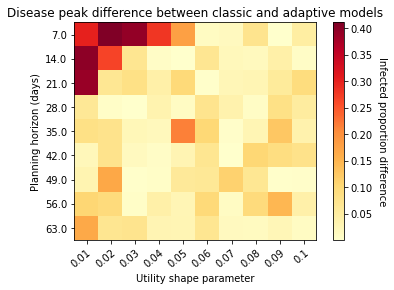

In [21]:
data_diff = pd.DataFrame({})
for v in epidist_data['V'].unique():
    for T in epidist_data['T'].unique():
        
        epidist = epidist_data[(epidist_data['V'] == v) & (epidist_data['T'] == T)]
        bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]
        
        mean = (epidist['i_mean']/n).tolist()
        meanb = (bepidist['i_mean']/n).tolist()
        
        diff = np.nanmax(mean) - np.nanmax(meanb)
        
        data_diff = pd.concat([data_diff, pd.DataFrame({
            'V': [v],
            'T': [T],
            'diff': [np.abs(diff)]
        })], ignore_index=True)
plot1_data = data_diff.pivot(index='V', columns='T', values='diff')
# Labels
xlabs = list(plot1_data.index)
ylabs = plot1_data.columns.tolist()
data = np.transpose(np.abs(plot1_data.values))

for dat in data:
    vals = [str(round(val, 4)) for val in list(dat)]
    vals = f"{{{','.join(vals)}}},"
    print(vals)

# Heat map
fig, ax = plt.subplots()
im = ax.imshow(data, cmap = "YlOrRd")

# Add the labels
# We want to show all ticks...
ax.set_xticks(np.arange(len(xlabs)))
ax.set_yticks(np.arange(len(ylabs)))
# ... and label them with the respective list entries
ax.set_xticklabels(xlabs)
ax.set_yticklabels(ylabs)

# Rotate the labels of the X-axis
plt.setp(ax.get_xticklabels(), rotation = 40,
         ha = "right", rotation_mode = "anchor")

# Add the color bar
cbar = ax.figure.colorbar(im, ax = ax)
cbar.ax.set_ylabel("Infected proportion difference", rotation = -90, va = "bottom")
plt.title(f"Disease peak difference between classic and adaptive models")
plt.xlabel("Utility shape parameter")
plt.ylabel("Planning horizon (days)")
plt.show()

### Main figure: global vs local efforts

0.5711762324748587


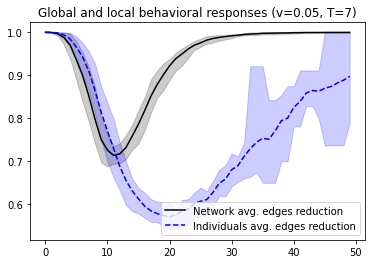

In [22]:
v = 0.05
T = 7
n = 500
epidist = epidist_data[(epidist_data['V'] == v) & (epidist_data['T'] == T)]
bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]

mean_all = bepidist['edgecount_mean'].tolist()
lower_all = bepidist['edgecount_min'].tolist()
upper_all = bepidist['edgecount_max'].tolist()

mean_sus = bepidist['suscedgecount_mean'].tolist()
lower_sus = bepidist['suscedgecount_min'].tolist()
upper_sus = bepidist['suscedgecount_max'].tolist()

print(np.nanmin(bepidist['suscedgecount_mean'].tolist()))

plt.figure()
plt.plot(mean_all[0:50],'-k', label="Network avg. edges reduction")
plt.fill_between(list(range(len(mean_all[0:50]))), upper_all[0:50], lower_all[0:50], color="k", alpha=0.2)
plt.plot(mean_sus[0:50], linestyle='--', color='b', label="Individuals avg. edges reduction")
plt.fill_between(list(range(len(mean_sus[0:50]))), upper_sus[0:50], lower_sus[0:50], color="b", alpha=0.2)
plt.title(f"Global and local behavioral responses (v={v}, T={T})")
plt.legend(loc="lower right")
plt.show()

### Min Avg. Edge Reduction (Global/Local)

{0.6686,0.6739,0.6707,0.7015,0.7137,0.8005,0.8985,0.9234,0.9405,0.9682},
{0.681,0.7048,0.8606,0.9556,0.967,0.9894,1.0,1.0,1.0,1.0},
{0.7137,0.9179,0.9749,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{0.8522,0.9743,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{0.9668,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{0.9837,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},


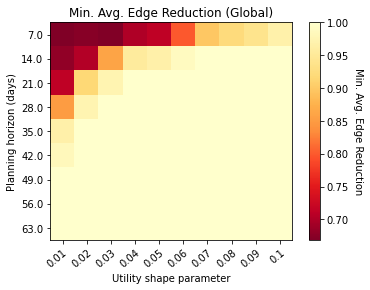

In [23]:
data_min = pd.DataFrame({})
for v in epidist_data['V'].unique():
    for T in epidist_data['T'].unique():
        bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]
        
        mean_sus = bepidist['edgecount_mean'].tolist()
        min_ctc_sus = np.nanmin(mean_sus)
        
        data_min = pd.concat([data_min, pd.DataFrame({
            'V': [v],
            'T': [T],
            'min': [min_ctc_sus]
        })], ignore_index=True)
        
plot1_data = data_min.pivot(index='V', columns='T', values='min')
# Labels
xlabs = list(plot1_data.index)
ylabs = plot1_data.columns.tolist()
data = np.transpose(np.abs(plot1_data.values))

for dat in data:
    vals = [str(round(val, 4)) for val in list(dat)]
    vals = f"{{{','.join(vals)}}},"
    print(vals)

# Heat map
fig, ax = plt.subplots()
im = ax.imshow(data, cmap = cmap_r)

# Add the labels
# We want to show all ticks...
ax.set_xticks(np.arange(len(xlabs)))
ax.set_yticks(np.arange(len(ylabs)))
# ... and label them with the respective list entries
ax.set_xticklabels(xlabs)
ax.set_yticklabels(ylabs)

# Rotate the labels of the X-axis
plt.setp(ax.get_xticklabels(), rotation = 40,
         ha = "right", rotation_mode = "anchor")

# Add the color bar
cbar = ax.figure.colorbar(im, ax = ax)
cbar.ax.set_ylabel("Min. Avg. Edge Reduction", rotation = -90, va = "bottom")
plt.title(f"Min. Avg. Edge Reduction (Global)")
plt.xlabel("Utility shape parameter")
plt.ylabel("Planning horizon (days)")
plt.show()

{0.6379,0.6456,0.6418,0.5825,0.5712,0.6948,0.8035,0.9442,0.8776,0.9643},
{0.6364,0.5926,0.7011,0.973,0.9805,0.9936,1.0,1.0,1.0,1.0},
{0.6704,0.9231,0.9857,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{0.8975,0.9844,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{0.9802,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{0.9908,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},


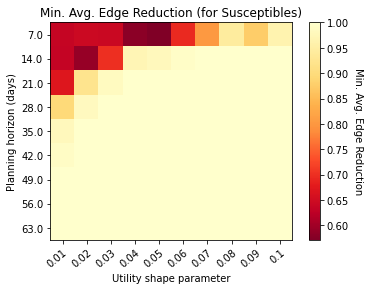

In [25]:
data_min = pd.DataFrame({})
for v in epidist_data['V'].unique():
    for T in epidist_data['T'].unique():
        bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]
        
        mean_sus = bepidist['suscedgecount_mean'].tolist()
        min_ctc_sus = np.nanmin(mean_sus)
        
        data_min = pd.concat([data_min, pd.DataFrame({
            'V': [v],
            'T': [T],
            'min': [min_ctc_sus]
        })], ignore_index=True)
        
plot1_data = data_min.pivot(index='V', columns='T', values='min')
# Labels
xlabs = list(plot1_data.index)
ylabs = plot1_data.columns.tolist()
data = np.transpose(np.abs(plot1_data.values))

for dat in data:
    vals = [str(round(val, 4)) for val in list(dat)]
    vals = f"{{{','.join(vals)}}},"
    print(vals)

# Heat map
fig, ax = plt.subplots()
im = ax.imshow(data, cmap = cmap_r)

# Add the labels
# We want to show all ticks...
ax.set_xticks(np.arange(len(xlabs)))
ax.set_yticks(np.arange(len(ylabs)))
# ... and label them with the respective list entries
ax.set_xticklabels(xlabs)
ax.set_yticklabels(ylabs)

# Rotate the labels of the X-axis
plt.setp(ax.get_xticklabels(), rotation = 40,
         ha = "right", rotation_mode = "anchor")

# Add the color bar
cbar = ax.figure.colorbar(im, ax = ax)
cbar.ax.set_ylabel("Min. Avg. Edge Reduction", rotation = -90, va = "bottom")
plt.title(f"Min. Avg. Edge Reduction (for Susceptibles)")
plt.xlabel("Utility shape parameter")
plt.ylabel("Planning horizon (days)")
plt.show()

### Day lag between min edge reductions (Global/Local)

{11,9,10,9,9,12,15,0,20,12},
{12,11,12,1,0,0,0,0,0,0},
{11,17,1,0,0,0,0,0,0,0},
{0,0,0,0,0,0,0,0,0,0},
{0,0,0,0,0,0,0,0,0,0},
{1,0,0,0,0,0,0,0,0,0},
{0,0,0,0,0,0,0,0,0,0},
{0,0,0,0,0,0,0,0,0,0},
{0,0,0,0,0,0,0,0,0,0},


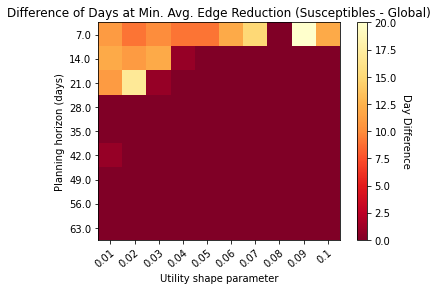

In [26]:
##### Reverse colormap
import matplotlib as mpl

def reverse_colourmap(cmap, name = 'my_cmap_r'):
    """
    In: 
    cmap, name 
    Out:
    my_cmap_r

    Explanation:
    t[0] goes from 0 to 1
    row i:   x  y0  y1 -> t[0] t[1] t[2]
                   /
                  /
    row i+1: x  y0  y1 -> t[n] t[1] t[2]

    so the inverse should do the same:
    row i+1: x  y1  y0 -> 1-t[0] t[2] t[1]
                   /
                  /
    row i:   x  y1  y0 -> 1-t[n] t[2] t[1]
    """        
    reverse = []
    k = []   

    for key in cmap._segmentdata:    
        k.append(key)
        channel = cmap._segmentdata[key]
        data = []

        for t in channel:                    
            data.append((1-t[0],t[2],t[1]))            
        reverse.append(sorted(data))    

    LinearL = dict(zip(k,reverse))
    my_cmap_r = mpl.colors.LinearSegmentedColormap(name, LinearL) 
    return my_cmap_r
cmap = mpl.cm.YlOrRd
cmap_r = reverse_colourmap(cmap)

# ------- #

data_min = pd.DataFrame({})
for v in epidist_data['V'].unique():
    for T in epidist_data['T'].unique():
        bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]
        
        mean_ctc_ = bepidist['edgecount_mean'].tolist()
        min_ctc_day_ = np.nanargmin(mean_ctc_)
        
        mean_ctc_sus_ = bepidist['suscedgecount_mean'].tolist()
        min_ctc_day_sus_ = np.nanargmin(mean_ctc_sus_)
        
        day_lag_ = min_ctc_day_sus_ - min_ctc_day_
        
        data_min = pd.concat([data_min, pd.DataFrame({
            'V': [v],
            'T': [T],
            'min': [day_lag_]
        })], ignore_index=True)
        
plot1_data = data_min.pivot(index='V', columns='T', values='min')
# Labels
xlabs = list(plot1_data.index)
ylabs = plot1_data.columns.tolist()
data = np.transpose(np.abs(plot1_data.values))

for dat in data:
    vals = [str(round(val, 4)) for val in list(dat)]
    vals = f"{{{','.join(vals)}}},"
    print(vals)

# Heat map
fig, ax = plt.subplots()
im = ax.imshow(data, cmap = cmap_r)

# Add the labels
# We want to show all ticks...
ax.set_xticks(np.arange(len(xlabs)))
ax.set_yticks(np.arange(len(ylabs)))
# ... and label them with the respective list entries
ax.set_xticklabels(xlabs)
ax.set_yticklabels(ylabs)

# Rotate the labels of the X-axis
plt.setp(ax.get_xticklabels(), rotation = 40,
         ha = "right", rotation_mode = "anchor")

# Add the color bar
cbar = ax.figure.colorbar(im, ax = ax)
cbar.ax.set_ylabel("Day Difference", rotation = -90, va = "bottom")
plt.title(f"Difference of Days at Min. Avg. Edge Reduction (Susceptibles - Global)")
plt.xlabel("Utility shape parameter")
plt.ylabel("Planning horizon (days)")
plt.show()

### Population distributions

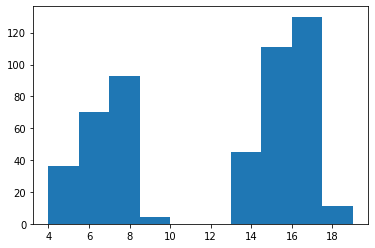

In [27]:
from scipy.stats import norm
n = 500
x = [norm(7, 1), norm(16, 1)]
draw = np.random.choice([0, 1], n, p=[0.4, 0.6])
y = [x[i].rvs() for i in draw]
y = [int(yy) for yy in y]
plt.hist(y)
plt.show()

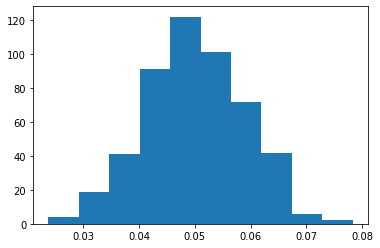

In [28]:
v_dist = norm(0.05, 0.009)
v_vals = [v_dist.rvs() for _ in range(n)]
plt.hist(v_vals)
plt.show()

In [29]:
bepidist_data = pd.read_csv('./Data/Distribution_bepidist.csv')
bepidist_data =  bepidist_data.drop(columns=['Unnamed: 0']).iloc[1: , :]
bepidist_data.columns = ['day', 's_mean', 's_min', 's_max', 'i_mean', 'i_min', 'i_max', 
'r_mean', 'r_min', 'r_max', 'edgecount_mean', 'edgecount_min', 'edgecount_max',
'suscedgecount_mean', 'suscedgecount_min', 'suscedgecount_max']
bepidist_data

,day,s_mean,s_min,s_max,i_mean,i_min,i_max,r_mean,r_min,r_max,edgecount_mean,edgecount_min,edgecount_max,suscedgecount_mean,suscedgecount_min,suscedgecount_max
1,1.0,497.7,499,495,2.05,4,1,0.25,3,0,0.9997679257362355,1.0,0.998719590268886,0.999886874965983,1.0,0.9994044188525035
2,2.0,495.45,499,490,4.15,10,1,0.4,3,0,0.9988236235595391,1.0,0.9950384122919335,0.999423851868616,1.0,0.9976581202707023
3,3.0,491.2,498,478,8.1,21,2,0.7,3,0,0.9958866837387964,1.0,0.9847951344430218,0.9979331391441878,1.0,0.9924338466742718
4,4.0,482.85,497,457,16.1,41,3,1.05,4,0,0.9883562740076824,0.9993597951344431,0.961427656850192,0.9938728584623189,0.9997165319392802,0.9786145965218015
5,5.0,469.45,495,427,28.05,64,5,2.5,9,0,0.9768886043533931,0.998719590268886,0.9433418693982074,0.9871830356360685,0.9994274785839388,0.9660447725288805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,196.0,0.25,1,0,0.2,1,0,499.55,500,498,1.0,1.0,1.0,1.0,1.0,1.0
197,197.0,0.25,1,0,0.15,1,0,499.6,500,498,1.0,1.0,1.0,1.0,1.0,1.0
198,198.0,0.25,1,0,0.15,1,0,499.6,500,498,1.0,1.0,1.0,1.0,1.0,1.0
199,199.0,0.25,1,0,0.15,1,0,499.6,500,498,1.0,1.0,1.0,1.0,1.0,1.0


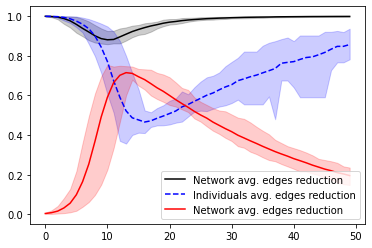

In [30]:
bepidist = bepidist_data.copy()

i_mean = bepidist['i_mean'].astype(float).tolist()
i_mean = [i/500 for i in i_mean]

i_min = bepidist['i_min'].astype(float).tolist()
i_min = [i/500 for i in i_min]

i_max = bepidist['i_max'].astype(float).tolist()
i_max = [i/500 for i in i_max]

mean_all = bepidist['edgecount_mean'].astype(float).tolist()
lower_all = bepidist['edgecount_min'].astype(float).tolist()
upper_all = bepidist['edgecount_max'].astype(float).tolist()

mean_sus = bepidist['suscedgecount_mean'].astype(float).tolist()
lower_sus = bepidist['suscedgecount_min'].astype(float).tolist()
upper_sus = bepidist['suscedgecount_max'].astype(float).tolist()

plt.figure()
plt.plot(mean_all[0:50],'-k', label="Network avg. edges reduction")
plt.fill_between(list(range(len(mean_all[0:50]))), upper_all[0:50], lower_all[0:50], color="k", alpha=0.2)
plt.plot(mean_sus[0:50], linestyle='--', color='b', label="Individuals avg. edges reduction")
plt.fill_between(list(range(len(mean_sus[0:50]))), upper_sus[0:50], lower_sus[0:50], color="b", alpha=0.2)
plt.plot(i_mean[0:50],'-r', label="Network avg. edges reduction")
plt.fill_between(list(range(len(i_mean[0:50]))), i_max[0:50], i_min[0:50], color="r", alpha=0.2)
plt.legend(loc="lower right")
plt.show()

In [17]:
# ','.join([str(m) for m in i_min])

In [32]:
bepidist_data = pd.read_csv('./Data/Distribution_bepidist.csv')
bepidist_data =  bepidist_data.drop(columns=['Unnamed: 0']).iloc[1: , :]
bepidist_data.columns = ['day', 's_mean', 's_min', 's_max', 'i_mean', 'i_min', 'i_max', 
'r_mean', 'r_min', 'r_max', 'edgecount_mean', 'edgecount_min', 'edgecount_max',
'suscedgecount_mean', 'suscedgecount_min', 'suscedgecount_max']
bepidist_data = bepidist_data.apply(pd.to_numeric)
bepidist_data

,day,s_mean,s_min,s_max,i_mean,i_min,i_max,r_mean,r_min,r_max,edgecount_mean,edgecount_min,edgecount_max,suscedgecount_mean,suscedgecount_min,suscedgecount_max
1,1.0,497.70,499,495,2.05,4,1,0.25,3,0,0.999768,1.00000,0.998720,0.999887,1.000000,0.999404
2,2.0,495.45,499,490,4.15,10,1,0.40,3,0,0.998824,1.00000,0.995038,0.999424,1.000000,0.997658
3,3.0,491.20,498,478,8.10,21,2,0.70,3,0,0.995887,1.00000,0.984795,0.997933,1.000000,0.992434
4,4.0,482.85,497,457,16.10,41,3,1.05,4,0,0.988356,0.99936,0.961428,0.993873,0.999717,0.978615
5,5.0,469.45,495,427,28.05,64,5,2.50,9,0,0.976889,0.99872,0.943342,0.987183,0.999427,0.966045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,196.0,0.25,1,0,0.20,1,0,499.55,500,498,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000
197,197.0,0.25,1,0,0.15,1,0,499.60,500,498,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000
198,198.0,0.25,1,0,0.15,1,0,499.60,500,498,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000
199,199.0,0.25,1,0,0.15,1,0,499.60,500,498,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000


In [33]:
# mean1 = [str(round(v, 5)) for v in bepidist_data['suscedgecount_mean'].tolist()]
# mean1 = f"{{{','.join(mean1)}}};"
# print(mean1)

### Bifurcation plot examination

In [45]:
epidist_data = pd.read_csv('./Data/epidist_bifurcation.csv')
bepidist_data = pd.read_csv('./Data/bepidist_bifurcation.csv')

In [46]:
epidist_data =  epidist_data.drop(columns=['Unnamed: 0']).iloc[1: , :]
epidist_data.columns = ['day', 's_mean', 's_min', 's_max', 'i_mean', 'i_min', 'i_max', 
'r_mean', 'r_min', 'r_max', 'pi', 'pr']
epidist_data = epidist_data.apply(pd.to_numeric)
epidist_data

,day,s_mean,s_min,s_max,i_mean,i_min,i_max,r_mean,r_min,r_max,pi,pr
1,1.0,499.0,499,499,1.0,1,1,0.0,0,0,0.0,0.04
2,2.0,499.0,499,499,1.0,1,1,0.0,0,0,0.0,0.04
3,3.0,499.0,499,499,1.0,1,1,0.0,0,0,0.0,0.04
4,4.0,499.0,499,499,1.0,1,1,0.0,0,0,0.0,0.04
5,5.0,499.0,499,499,1.0,1,1,0.0,0,0,0.0,0.04
...,...,...,...,...,...,...,...,...,...,...,...,...
5996,196.0,0.0,0,0,0.3,1,0,499.7,500,499,0.1,0.04
5997,197.0,0.0,0,0,0.3,1,0,499.7,500,499,0.1,0.04
5998,198.0,0.0,0,0,0.2,1,0,499.8,500,499,0.1,0.04
5999,199.0,0.0,0,0,0.2,1,0,499.8,500,499,0.1,0.04


In [47]:
bepidist_data = bepidist_data.drop(columns=['Unnamed: 0']).iloc[1: , :]
bepidist_data.columns = ['day', 's_mean', 's_min', 's_max', 'i_mean', 'i_min', 'i_max', 
                         'r_mean', 'r_min', 'r_max', 'edgecount_mean', 'edgecount_min', 'edgecount_max',
'suscedgecount_mean', 'suscedgecount_min', 'suscedgecount_max', 'pi', 'pr']
bepidist_data = bepidist_data.apply(pd.to_numeric)
bepidist_data

,day,s_mean,s_min,s_max,i_mean,i_min,i_max,r_mean,r_min,r_max,edgecount_mean,edgecount_min,edgecount_max,suscedgecount_mean,suscedgecount_min,suscedgecount_max,pi,pr
1,1.0,499.0,499,499,1.0,1,1,0.0,0,0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.04
2,2.0,499.0,499,499,1.0,1,1,0.0,0,0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.04
3,3.0,499.0,499,499,1.0,1,1,0.0,0,0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.04
4,4.0,499.0,499,499,0.9,1,0,0.1,1,0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.04
5,5.0,499.0,499,499,0.9,1,0,0.1,1,0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5996,196.0,0.0,0,0,0.5,1,0,499.5,500,499,1.0,1.0,1.0,NaN,NaN,NaN,0.1,0.04
5997,197.0,0.0,0,0,0.5,1,0,499.5,500,499,1.0,1.0,1.0,NaN,NaN,NaN,0.1,0.04
5998,198.0,0.0,0,0,0.4,1,0,499.6,500,499,1.0,1.0,1.0,NaN,NaN,NaN,0.1,0.04
5999,199.0,0.0,0,0,0.3,1,0,499.7,500,499,1.0,1.0,1.0,NaN,NaN,NaN,0.1,0.04


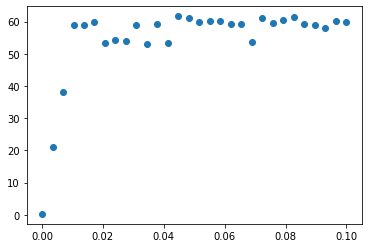

In [48]:
dat = pd.DataFrame(epidist_data.groupby(['pi'])['i_mean'].mean()).reset_index()
plt.scatter(dat['pi'], dat['i_mean'])
plt.show()

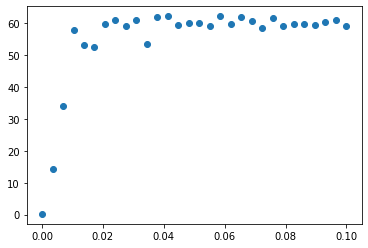

In [49]:
dat = pd.DataFrame(bepidist_data.groupby(['pi'])['i_mean'].mean()).reset_index()
plt.scatter(dat['pi'], dat['i_mean'])
plt.show()

In [50]:
dat1 = epidist_data[epidist_data['pi']==0.0069]
dat2 = bepidist_data[bepidist_data['pi']==0.0069]

115.2
90.4
38.2795
33.93600000000001


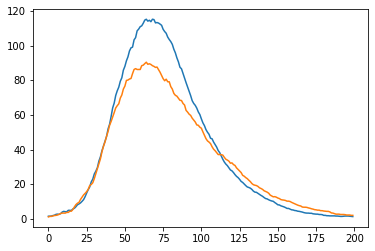

In [51]:
print(dat1['i_mean'].max())
print(dat2['i_mean'].max())
print(dat1['i_mean'].mean())
print(dat2['i_mean'].mean())
plt.plot(range(dat1.shape[0]), dat1['i_mean'], range(dat1.shape[0]), dat2['i_mean'])
plt.show()

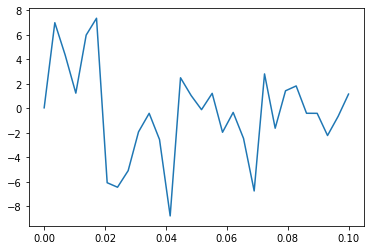

In [52]:
diffs = []
mean_diffs = []
for pi in epidist_data['pi'].unique().tolist():
    dat1 = epidist_data[epidist_data['pi']==pi]
    dat2 = bepidist_data[bepidist_data['pi']==pi]
    diff = dat1['i_mean'].max() - dat2['i_mean'].max()
    diffs.append(diff)
    mean_diff = dat1['i_mean'].mean() - dat2['i_mean'].mean()
    mean_diffs.append(mean_diff)
plt.plot(epidist_data['pi'].unique().tolist(), mean_diffs)
plt.show()

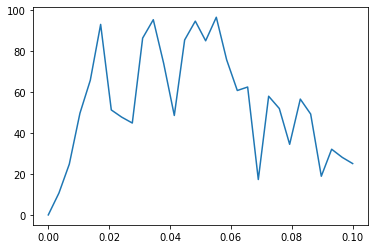

In [53]:
plt.plot(epidist_data['pi'].unique().tolist(), diffs)
plt.show()

## Sensitivity to network connectivity

Experiment with Erdos-Renyi

In [19]:
bepidist_data_c = pd.read_csv('./Data/bepidist_ntwk_conn_erdos_renyi.csv')
bepidist_data_c = bepidist_data_c.drop(columns=['Unnamed: 0']).iloc[1: , :]
bepidist_data_c.columns = ['day', 's_mean', 's_min', 's_max', 'i_mean', 'i_min', 'i_max', 
                         'r_mean', 'r_min', 'r_max', 'edgecount_mean', 'edgecount_min', 'edgecount_max',
'suscedgecount_mean', 'suscedgecount_min', 'suscedgecount_max', 'ped']
bepidist_data_c = bepidist_data_c.apply(pd.to_numeric)
conns = bepidist_data_c['ped'].unique().tolist()[5:]

In [20]:
day_lags = []
for conn in conns:

    bepidist = bepidist_data_c.copy()
    bepidist = bepidist[bepidist['ped'] == conn]

    i_mean = bepidist['i_mean'].astype(float).tolist()
    i_mean = [i/500 for i in i_mean]

    i_min = bepidist['i_min'].astype(float).tolist()
    i_min = [i/500 for i in i_min]

    i_max = bepidist['i_max'].astype(float).tolist()
    i_max = [i/500 for i in i_max]

    mean_all = bepidist['edgecount_mean'].astype(float).tolist()
    lower_all = bepidist['edgecount_min'].astype(float).tolist()
    upper_all = bepidist['edgecount_max'].astype(float).tolist()

    mean_sus = bepidist['suscedgecount_mean'].astype(float).tolist()
    lower_sus = bepidist['suscedgecount_min'].astype(float).tolist()
    upper_sus = bepidist['suscedgecount_max'].astype(float).tolist()
    
    day_lags.append(np.nanargmin(mean_sus) - np.nanargmin(mean_all))

    # plt.figure()
    # days = 50
    # plt.plot(mean_all[0:days],'-k', label="Network avg. edges reduction")
    # plt.fill_between(list(range(len(mean_all[0:days]))), upper_all[0:days], lower_all[0:days], color="k", alpha=0.2)
    # plt.plot(mean_sus[0:days], linestyle='--', color='b', label="Individuals avg. edges reduction")
    # plt.fill_between(list(range(len(mean_sus[0:days]))), upper_sus[0:days], lower_sus[0:days], color="b", alpha=0.2)
    # plt.plot(i_mean[0:days],'-r', label="Infected Proportion")
    # plt.fill_between(list(range(len(i_mean[0:days]))), i_max[0:days], i_min[0:days], color="r", alpha=0.2)
    # plt.legend(loc="lower right")
    # plt.title(f"Edge reduction (global/local) and infected population. Connectivity={conn}")
    # plt.xlabel("Time")
    # plt.show()

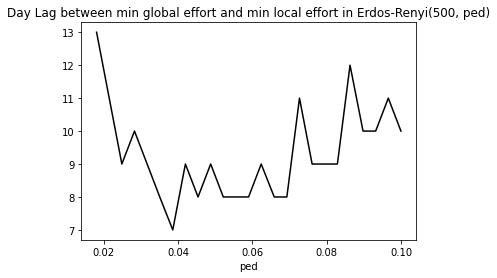

In [21]:
plt.figure()
plt.plot(conns, day_lags,'-k', label="Network avg. edges reduction")
plt.title("Day Lag between min global effort and min local effort in Erdos-Renyi(500, ped)")
plt.xlabel("ped")
plt.show()

### Barabasi Albert Network

In [15]:
bepidist_data_ba = pd.read_csv('./Data/bepidist_ntwk_barabasi_albert.csv')
bepidist_data_ba = bepidist_data_ba.drop(columns=['Unnamed: 0']).iloc[1: , :]
bepidist_data_ba.columns = ['day', 's_mean', 's_min', 's_max', 'i_mean', 'i_min', 'i_max', 
                         'r_mean', 'r_min', 'r_max', 'edgecount_mean', 'edgecount_min', 'edgecount_max',
'suscedgecount_mean', 'suscedgecount_min', 'suscedgecount_max', 'm']
bepidist_data_ba = bepidist_data_ba.apply(pd.to_numeric)
mms = bepidist_data_ba['m'].unique().tolist()

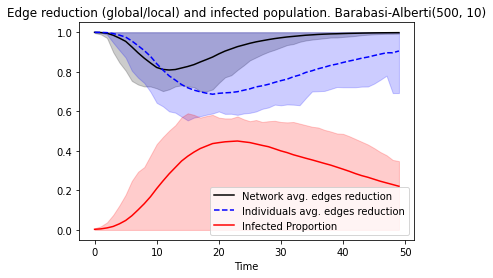

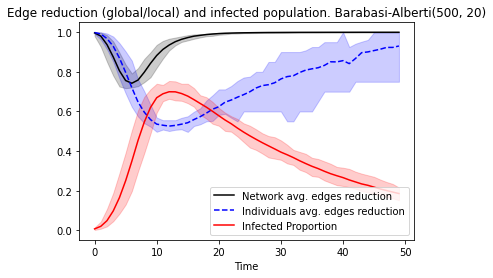

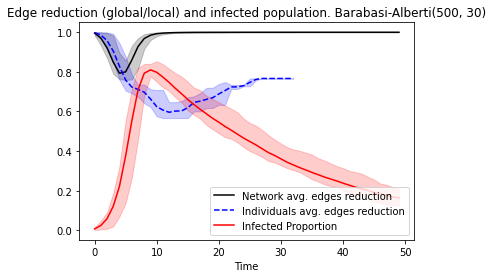

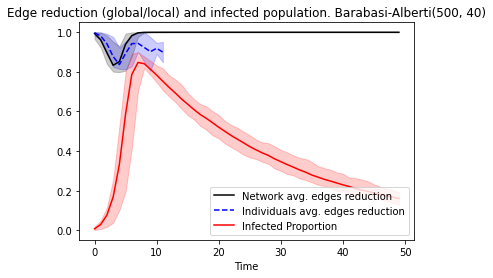

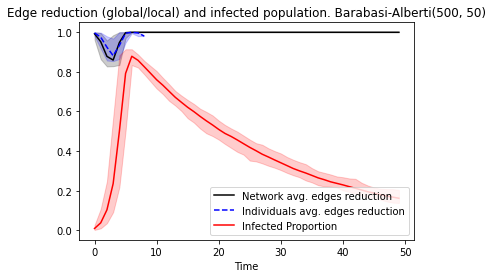

In [12]:
day_lags = []

for m in mms:
    
    bepidist = bepidist_data_ba.copy()
    bepidist = bepidist[bepidist['m'] == m]

    i_mean = bepidist['i_mean'].astype(float).tolist()
    i_mean = [i/500 for i in i_mean]

    i_min = bepidist['i_min'].astype(float).tolist()
    i_min = [i/500 for i in i_min]

    i_max = bepidist['i_max'].astype(float).tolist()
    i_max = [i/500 for i in i_max]

    mean_all = bepidist['edgecount_mean'].astype(float).tolist()
    lower_all = bepidist['edgecount_min'].astype(float).tolist()
    upper_all = bepidist['edgecount_max'].astype(float).tolist()

    mean_sus = bepidist['suscedgecount_mean'].astype(float).tolist()
    lower_sus = bepidist['suscedgecount_min'].astype(float).tolist()
    upper_sus = bepidist['suscedgecount_max'].astype(float).tolist()

    day_lags.append(np.nanargmin(mean_sus) - np.nanargmin(mean_all))

    # plt.figure()
    # days = 50
    # plt.plot(mean_all[0:days],'-k', label="Network avg. edges reduction")
    # plt.fill_between(list(range(len(mean_all[0:days]))), upper_all[0:days], lower_all[0:days], color="k", alpha=0.2)
    # plt.plot(mean_sus[0:days], linestyle='--', color='b', label="Individuals avg. edges reduction")
    # plt.fill_between(list(range(len(mean_sus[0:days]))), upper_sus[0:days], lower_sus[0:days], color="b", alpha=0.2)
    # plt.plot(i_mean[0:days],'-r', label="Infected Proportion")
    # plt.fill_between(list(range(len(i_mean[0:days]))), i_max[0:days], i_min[0:days], color="r", alpha=0.2)
    # plt.legend(loc="lower right")
    # plt.title(f"Edge reduction (global/local) and infected population. Barabasi-Alberti(500, {int(m)})")
    # plt.xlabel("Time")
    # plt.show()

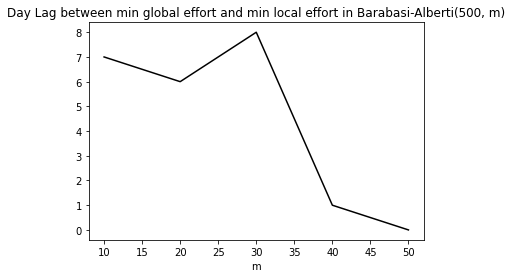

In [11]:
plt.figure()
days = 50
plt.plot(mms, day_lags,'-k', label="Network avg. edges reduction")
plt.title("Day Lag between min global effort and min local effort in Barabasi-Alberti(500, m)")
plt.xlabel("m")
plt.show()

### Small world network

## Articles of interest:
- https://www.pnas.org/doi/10.1073/pnas.2123355119
- https://journals.aps.org/pre/pdf/10.1103/PhysRevE.88.042802
- https://journals.aps.org/pre/pdf/10.1103/PhysRevE.77.066101
- https://journals.aps.org/prl/pdf/10.1103/PhysRevLett.96.208701
- https://www.sciencedirect.com/science/article/pii/S0022039618304182
- https://ieeexplore.ieee.org/abstract/document/8502826